# Downloading the data

Download the SPROUT files from
https://figshare.com/projects/Systematic_characterization_of_genome_editing_in_primary_T_cells_reveals_proximal_genomic_insertions_and_enables_machine_learning_prediction_of_CRISPR-Cas9_DNA_repair_outcomes/37166

Specifically, in the folder "Analyzed T-Cell DNA Repair Outcomes":

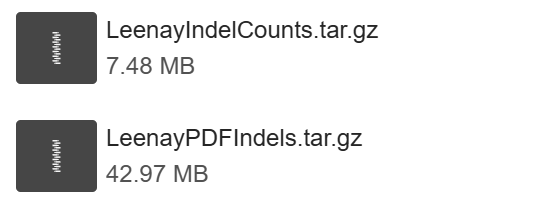

Unzip both inside CROP/data/SPROUT/

Should now have folders:
CROP/data/SPROUT/LeenayIndelCounts/counts  
and  
CROP/data/SPROUT/LeenayPDFIndels/indels


# Versions

We will need the following versions (shown as output for this cell):

In [21]:
import sys
import pdfplumber
import os
import pandas as pd
print("Python version:", sys.version)
print("pdfplumber version:", pdfplumber.__version__)
print("Pandas version:", pd.__version__)

Python version: 3.11.13 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 13:03:15) [MSC v.1929 64 bit (AMD64)]
pdfplumber version: 0.11.8
Pandas version: 2.3.0


# Get sequences

Instead of messing with R, for simplicity we keep the sequence extraction to python. This requires us to analyze the PDF files given by the paper, in order to map from sequences to file names, since the file names for the counts are similar to the file names in which we can find the sequences.

In [1]:
PATH = "../data/SPROUT/LeenayPDFIndels/indels"

In [3]:
# get all pdf files in the directory
pdf_files = [f for f in os.listdir(PATH) if f.endswith('.pdf')]
print(f"Found {len(pdf_files)} PDF files.")

Found 1985 PDF files.


In [ ]:
def extract_reference_sequence(pdf_path):
    with pdfplumber.open(pdf_path) as pdf:
        page = pdf.pages[0]

        # Get all text from the first page
        text = page.extract_text()
        if text is None:
            print("No extractable text found.")
            return None

        lines = text.split("\n")

        # Find the top line that starts with "Reference"
        for line in lines:
            if line.strip().startswith("Reference"):
                parts = line.split()

                # Keep only nucleotide strings (A/C/G/T only)
                seq = "".join(
                    p for p in parts if all(c in "ACGT" for c in p)
                )

                return seq

    return None

Lets test it on some PDF file

In [5]:
first_file = pdf_files[0]
print(f"First file: {first_file}")
first_file_path = os.path.join(PATH, first_file)

ref_seq = extract_reference_sequence(first_file_path)

if ref_seq:
    print("Reference sequence:")
    print(ref_seq)
else:
    print("Could not extract reference sequence.")

First file: ABCB10-01-1891.pdf
Reference sequence:
CAGCCACTCTCTGGATTTCCTCAGCGGTCACAGAGGAAGGGTCATCAGCACCATAAGCAA


This is the correct output, so we move on to do it for all files

In [6]:
# run on all pdf filesto get all sequences
sequences = {}
for i, pdf_file in enumerate(pdf_files):
    pdf_path = os.path.join(PATH, pdf_file)
    print(f"Processing file: {pdf_file}")
    try:
        seq = extract_reference_sequence(pdf_path)
        if seq:
            sequences[pdf_file] = seq
        else:
            sequences[pdf_file] = "Could not extract sequence"
    except Exception as e:
        sequences[pdf_file] = f"Error: {e}"
    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1} / {len(pdf_files)} files.")

Processing file: ABCB10-01-1891.pdf
Processing file: ABCB10-02-1892.pdf
Processing file: ABCB10-03-1893.pdf
Processing file: ABCD3-01-1862.pdf
Processing file: ABCD3-02-1863.pdf
Processing file: ABCD3-03-1864.pdf
Processing file: ACBD3-01-88.pdf
Processing file: ACBD3-02-89.pdf
Processing file: ACBD3-03-90.pdf
Processing file: ACBD5-01-1856.pdf
Processed 10 / 1985 files.
Processing file: ACBD5-02-1857.pdf
Processing file: ACBD5-03-1858.pdf
Processing file: ACOT8-01-2160.pdf
Processing file: ACOT8-02-2161.pdf
Processing file: ACOT8-03-2162.pdf
Processing file: ACSL3-01-1102.pdf
Processing file: ACSL3-01-481.pdf
Processing file: ACSL3-02-1151.pdf
Processing file: ACSL3-02-482.pdf
Processing file: ACSL3-03-1104.pdf
Processed 20 / 1985 files.
Processing file: ACSL3-03-483.pdf
Processing file: AEBP2-01-989.pdf
Processing file: AEBP2-02-993.pdf
Processing file: AEBP2-03-1026.pdf
Processing file: AFF1-01-2074.pdf
Processing file: AFF1-01-937.pdf
Processing file: AFF1-02-2075.pdf
Processing fi

Save the mapping for some visual inspection if needed

In [7]:
# save the sequences to a text file
with open("extracted_sequences.txt", "w") as f:
    for pdf_file, seq in sequences.items():
        f.write(f"{pdf_file}\t{seq}\n")

print("Extraction complete. Sequences saved to extracted_sequences.txt.")

Extraction complete. Sequences saved to extracted_sequences.txt.


In [8]:
# load the sequences back
loaded_sequences = {}
with open("extracted_sequences.txt", "r") as f:
    for line in f:
        pdf_file, seq = line.strip().split("\t")
        loaded_sequences[pdf_file] = seq

In [9]:
# find how many sequences were successfully extracted
successful_extractions = {
    k: v for k, v in loaded_sequences.items() if "Could not extract" not in v and "Error:" not in v
}
print(f"Successfully extracted {len(successful_extractions)} / {len(loaded_sequences)} sequences.")

Successfully extracted 1977 / 1985 sequences.


Lets find where the PAM is 

In [10]:
# find if there are positions which are always the nucleotide 'G'
position_counts = {}
for seq in successful_extractions.values():
    for i, nucleotide in enumerate(seq):
        if i not in position_counts:
            position_counts[i] = {}
        if nucleotide not in position_counts[i]:
            position_counts[i][nucleotide] = 0
        position_counts[i][nucleotide] += 1

for position, counts in position_counts.items():
    if len(counts) == 1 and 'G' in counts:
        print(f"Position {position} is always 'G'")

Position 34 is always 'G'
Position 35 is always 'G'


PAM is always at position 33

Now, we check if the number of sequences is the same as in literature - 1603

In [11]:
# check how many unique sequences there are
unique_sequences = set(successful_extractions.values())
print(f"Number of unique sequences: {len(unique_sequences)}")

Number of unique sequences: 1601


Missing 2!

In [12]:
# print all unsuccessful extractions and their errors
for pdf_file, msg in loaded_sequences.items():
    if "Could not extract" in msg or "Error:" in msg:
        print(f"{pdf_file}: {msg}")


print("\n\n")
# get those where we could not extract (not error)
not_extracted = {
    k: v for k, v in loaded_sequences.items() if "Could not extract" in v
}
print("Files where sequence could not be extracted:")
for pdf_file in not_extracted.keys():
    print(pdf_file)

ARHGEF12-03-1513.pdf: Error: No /Root object! - Is this really a PDF?
LRPPRC-01-1897.pdf: Error: No /Root object! - Is this really a PDF?
NARS2-03-634.pdf: Could not extract sequence
PUM2-02-1547.pdf: Error: No /Root object! - Is this really a PDF?
RAB31-03-780.pdf: Error: No /Root object! - Is this really a PDF?
TARS-03-628.pdf: Could not extract sequence
XPO4-03-2041.pdf: Error: No /Root object! - Is this really a PDF?
YWHAG-01-1699.pdf: Error: No /Root object! - Is this really a PDF?



Files where sequence could not be extracted:
NARS2-03-634.pdf
TARS-03-628.pdf


Seems 2 valid PDFs had an issue, so I add the sequences manually (by eye)

In [ ]:
manual_mapping = {
    "NARS2-03-634.pdf": "TCATACTCCAATAATCACATCCAATGACTCTGAGGGAGCTGGAGAACTTTTTCAACTTGA",
    "TARS-03-628.pdf": "AGATCTCTGCCGGGGTCCTCATGTTAGACACACGGGCAAAATTAAGGCTTTAAAAATACA"}


# merge the mapping of manual corrections with successful extractions
successful_extractions.update(manual_mapping)
print(f"Total sequences after manual corrections: {len(successful_extractions)}")

unique_sequences = set(successful_extractions.values())
print(f"Number of unique sequences after manual corrections: {len(unique_sequences)}")



Total sequences after manual corrections: 1979
Number of unique sequences after manual corrections: 1603


Now we have 1603 sequences!

In [14]:
# map unique sequences to files
seq_to_files = {}

for filename, seq in successful_extractions.items():
    if seq not in seq_to_files:
        seq_to_files[seq] = []
    seq_to_files[seq].append(filename)

# Map them to repair outcomes

In [15]:
from collections import defaultdict
import re

def parse_mutation_file(file_path, verbose=False):
    data = defaultdict(int)

    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()[1:]  # Skip header

    for line in lines:
        line = line.strip()
        if not line or '"' not in line:
            continue

        try:
            name = line.split('"')[1]
            counts_str = line.split('"')[2].lstrip(',')
            count_parts = counts_str.split(',')
            counts = sum(map(int, count_parts))
        except Exception:
            continue

        mutations = name.split(',')
        keys = []

        for mut in mutations:
            match = re.match(r'-?\d+:(\d+)([ID])', mut.strip())
            if match:
                length_str, mut_type = match.groups()
                try:
                    length = int(length_str)
                    key = length if mut_type == 'I' else -length
                    keys.append(key)
                except ValueError:
                    pass
            else:
                keys.append(0)
            

        combined_key = sum(keys) if keys else 0
        data[combined_key] += counts

        if verbose:
            print(f"{line.strip()}, \nCombined Key: {combined_key}, Counts: {counts}")

    return data


Visual "proof" this works

In [16]:
parse_mutation_file("..\data\SPROUT\LeenayIndelCounts\counts\counts-TFEC-03-827.txt", verbose=True)

"no variant",42358,43259, 
Combined Key: 0, Counts: 85617
"SNV:-1",169,101, 
Combined Key: 0, Counts: 270
"SNV:-2",32,82, 
Combined Key: 0, Counts: 114
"SNV:1",73,19, 
Combined Key: 0, Counts: 92
"SNV:-2,-1",68,12, 
Combined Key: 0, Counts: 80
"SNV:2",26,32, 
Combined Key: 0, Counts: 58
"SNV:-3",19,29, 
Combined Key: 0, Counts: 48
"SNV:-5",12,31, 
Combined Key: 0, Counts: 43
"SNV:3",18,25, 
Combined Key: 0, Counts: 43
"SNV:-8",19,16, 
Combined Key: 0, Counts: 35
"SNV:4",15,20, 
Combined Key: 0, Counts: 35
"SNV:-4",18,10, 
Combined Key: 0, Counts: 28
"SNV:-7",14,11, 
Combined Key: 0, Counts: 25
"SNV:5",12,11, 
Combined Key: 0, Counts: 23
"SNV:6",11,12, 
Combined Key: 0, Counts: 23
"SNV:-3,-2",20,0, 
Combined Key: 0, Counts: 20
"SNV:-6",12,8, 
Combined Key: 0, Counts: 20
"SNV:-4,-3,-1,1,2",15,0, 
Combined Key: 0, Counts: 15
"SNV:-1,1",0,14, 
Combined Key: 0, Counts: 14
"SNV:-3,-2,1",0,13, 
Combined Key: 0, Counts: 13
"SNV:-5,-4,-3,-2",8,0, 
Combined Key: 0, Counts: 8
"SNV:-4,-3,-2,2",0,7

defaultdict(int,
            {0: 88624,
             -1: 34586,
             -10: 12375,
             -5: 7341,
             -2: 7702,
             -3: 6702,
             -4: 8212,
             -6: 6153,
             -9: 5353,
             1: 4085,
             -7: 3584,
             -11: 3372,
             2: 2025,
             -29: 2550,
             -24: 2024,
             -15: 1820,
             -12: 1775,
             -8: 1596,
             -16: 1696,
             -13: 1300,
             -22: 965,
             -17: 689,
             -19: 1283,
             -20: 783,
             -28: 777,
             -33: 704,
             -37: 609,
             -26: 469,
             -14: 1183,
             -18: 1139,
             -47: 389,
             -25: 715,
             -39: 333,
             -34: 256,
             4: 344,
             -38: 295,
             -27: 479,
             -21: 545,
             -42: 199,
             -23: 480,
             -46: 197,
             -31: 387,
        

This just aggregates the outcomes between files

In [17]:
def parse_multiple_mutation_files(file_list):
    combined = defaultdict(int)

    for file_path in file_list:
        single_result = parse_mutation_file(file_path)
        for key, count in single_result.items():
            combined[key] += count

    return combined

In [18]:
# Step 1–3: Collect all mutation profiles + track global min/max key
mutation_dicts = []
global_min_key = float('inf')
global_max_key = float('-inf')

# make unique sequences into a list for iteration
unique_sequences = list(seq_to_files.keys())


for sequence in unique_sequences:
    paths = seq_to_files[sequence]
    # replace .pdf with .txt and make full paths under ../data/SPROUT/LeenayX
    paths = [
        os.path.join(
            "../data/SPROUT/LeenayIndelCounts/counts",
            "counts-" + os.path.splitext(os.path.basename(fname))[0] + ".txt"
        )
        for fname in paths
    ]
    # set genename (filename without extension) for downstream lookup
    genename = os.path.splitext(seq_to_files[sequence][0])[0]

    indel_dict = parse_multiple_mutation_files(paths)

    if indel_dict:
        local_min = min(indel_dict.keys())
        local_max = max(indel_dict.keys())
        global_min_key = min(global_min_key, local_min)
        global_max_key = max(global_max_key, local_max)
    mutation_dicts.append(indel_dict)

print(f"Global min key: {global_min_key}, Global max key: {global_max_key}")

Global min key: -99, Global max key: 88


In [ ]:
# Step 4: Construct DataFrame with all columns from min to max
key_range = list(range(global_min_key, global_max_key + 1))
mutation_df = pd.DataFrame(columns=key_range)

for indel_dict in mutation_dicts:
    row = [indel_dict.get(k, 0) for k in key_range]
    mutation_df.loc[len(mutation_df)] = row

# add unique sequences as a new column
mutation_df['sequence'] = unique_sequences

# add PAM index column to be always 33
mutation_df['PAM position'] = 33



# Arrange so sequence and PAM_index are the first columns
mutation_df = mutation_df[['sequence', 'PAM position'] + [col for col in mutation_df.columns if col not in ['sequence', 'PAM position']]]

# Remove the 0 mutation column if it exists - since we don't care about measuring on-target efficiency
if 0 in mutation_df.columns:
    mutation_df = mutation_df.drop(columns=[0])

# Step 5: Save DataFrame to CSV
mutation_df.to_csv("../data/SPROUT_T.csv", index=False)

# show first few rows
mutation_df.head()

,sequence,PAM position,-99,-98,-97,-96,-95,-94,-93,-92,...,79,80,81,82,83,84,85,86,87,88
0,CAGCCACTCTCTGGATTTCCTCAGCGGTCACAGAGGAAGGGTCATC...,33,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,AGTGAAAGCACTGTTGATTTGCCAGAACCACTTGGGCCAACCAGTG...,33,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,AGGAAGGGGCCTTTACCTGAGTGGCTTGTGCCAGGGAATCCTGAGT...,33,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,TACTCCTCATAGAGGTATTTAGTGAGCCTTACTCGGAAGCACAGTT...,33,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,TGCATTGCATGTGGTGGTTTGCAGTGGTATCATTGGTCGTAGCAGG...,33,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
